In [ ]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
from simulations.src import *

In [2]:
manifold_type = 'S1'

G_sampler_ls = [
    get_G_class(manifold_type, sampler, name, params) for sampler, name, params 
        in [
            (multimodal_sampler, '1-modal', {'tau2' : 0.05, 'num_modes' : 1}),
            (multimodal_sampler, '2-modal', {'tau2' : 0.05, 'num_modes' : 2}),
            (multimodal_sampler, '3-modal', {'tau2' : 0.05, 'num_modes' : 3}),
            (multimodal_sampler, '4-modal', {'tau2' : 0.01, 'num_modes' : 4}),
        ]
    ]

In [3]:
NMC = 3
n_samples = 500
sigma2_ls = np.linspace(0.005, 0.25, 6)
num_oracle_samples = 10000
oracle_bandwidth = 0.25
# ------------------------------------------------------------------------------------------------------------------------------------------------
df_sigma = mcsims_IncreasingSigma(
    manifold_type,
    n_samples,
    G_sampler_ls,
    sigma2_ls,
    num_oracle_samples,
    oracle_bandwidth,
    NMC, 
    bayes=True)

TypeError: oracle_denoiser() takes 5 positional arguments but 6 were given

In [4]:
NMC = 10
rho_ls = np.linspace(0.5, 0.005, 10)
M_ls = [ 7,7,7,7 ]

n_samples_ls = [50, 100, 250, 500]
test_size = 100
# ------------------------------------------------------------------------------------------------------------------------------------------------
df_N = mcsims_IncreasingN(
    manifold_type,
    n_samples_ls,
    M_ls,
    G_sampler_ls,
    sigma2_ls,
    rho_ls,
    test_size,
    num_oracle_samples,
    oracle_bandwidth,
    NMC)


In [5]:
wd = os.getcwd()
out_path = os.path.join(wd, "data", manifold_type, "df_sigma.csv")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_sigma.to_csv(out_path, index=False)
df_N.to_csv(os.path.join(wd, "data", manifold_type, "df_N.csv"), index=False)

----

In [6]:
def plot_mcsims(manifold_type, df_sigma, df_N, G_sampler_ls, savefig=None):
    df_long, df_summary = df_sigma, df_N

    K = len(G_sampler_ls)

    # Make row 0 shorter than rows 1 and 2
    fig, axs = plt.subplots(
        3, K,
        figsize=(20, 10),
        gridspec_kw={"height_ratios": [0.65, 1.0, 1.0], "hspace": 0.35, "wspace": 0.25},
    )

    for idx, G in enumerate(G_sampler_ls):
        if manifold_type == "S1":
            manifold = Hypersphere(1)
            ss = axs[0, idx].get_subplotspec()
            axs[0, idx].remove()
            axs[0, idx] = fig.add_subplot(ss, polar=True)
            axs[0, idx].set_title(f"'{G.name}'", fontsize=14)

            Theta = G.sample(1000)
            Theta = manifold.intrinsic_to_extrinsic_coords(
                manifold.extrinsic_to_intrinsic_coords(Theta) - np.pi / 12
            )

            f_scale = 0.3
            bottom = 0.105
            top = .5
            disk_r = 0.1
            grid_I = np.linspace(0, 2*np.pi, 50)
            on_X = manifold.intrinsic_to_extrinsic_coords( grid_I[:, None])
            hat_f = kernel_density_estimate("S1", Theta, 9, on_X)[1]
            hat_pos_f = np.maximum(hat_f, 0)
            normalised_hat_f = (hat_pos_f - hat_pos_f.min()) / (hat_pos_f.max() - hat_pos_f.min() + 1e-10)
            verts = [[
                    (grid_I[i], bottom),
                    (grid_I[i], bottom + f_scale * hat_pos_f[i]), (grid_I[i+1], bottom + f_scale * hat_pos_f[i+1]),
                    # (grid_I[i],top), (grid_I[i+1], bottom + top),
                    (grid_I[i+1], bottom)
                ] for i in range(len(grid_I) - 1)] # Create polygon vertices for each segment
            poly = PolyCollection(verts, facecolors=plt.colormaps['Reds'](normalised_hat_f[:-1]), 
                                alpha=0.85, edgecolors='none')
            axs[0,idx].add_collection(poly)

            axs[0,idx].set_ylim(0, bottom + hat_f.max()*f_scale)  
            axs[0,idx].set_yticks([])
            axs[0,idx].bar(0, disk_r, width=2*np.pi, bottom=0, color="white", edgecolor="none", align="edge", zorder=3)
            axs[0,idx].plot(grid_I, disk_r*np.ones_like(grid_I), color='black', linewidth=1.2, zorder=4)
            # S1_histogram(Theta, 30, axs[0, idx], "Reds")

        elif manifold_type == "S2":
            manifold = Hypersphere(2)
            ss = axs[0, idx].get_subplotspec()
            axs[0, idx].remove()
            axs[0, idx] = fig.add_subplot(ss, projection="mollweide")
            axs[0, idx].set_xticks([]); axs[0, idx].set_yticks([])
            axs[0, idx].grid(True, alpha=0.3)
            axs[0, idx].set_title(f"'{G.name}'", fontsize=14)

            grid_resolution = 100
            grid, grid_theta, grid_phi = S2grid(grid_resolution)
            hat_f = kernel_density_estimate("S2", G.sample(1000), 20, grid)[1].reshape(
                grid_resolution, grid_resolution
            )
            axs[0, idx].pcolormesh(
                grid_phi - np.pi,
                np.pi / 2 - grid_theta,
                hat_f,
                alpha=0.8,
                shading="auto",
                cmap="Reds",
                vmin=0.5 if G.name == "uniform" else None,
                vmax=0.5 if G.name == "uniform" else None,
            )
        else:
            raise ValueError("Unsupported manifold type. Supported types are 'S1' and 'S2'.")


        df_subset = df_long[df_long["G"] == G.name]
        sns.lineplot(
            data=df_subset,
            x="sigma2",
            y="Loss",
            hue="Loss Type",
            hue_order=["Naïve", "Oracle Denoised", "Oracle Bayes"],
            palette={"Naïve": "C0","Oracle Denoised": "C2","Oracle Bayes": "C4",},
            style="Loss Type",
            dashes={"Naïve": "","Oracle Denoised": (1, 1),"Oracle Bayes": (1, 1),},
            estimator="mean",
            errorbar=("ci", 68),
            marker="o",
            ax=axs[1, idx],
        )

       
        axs[1, idx].set_xlabel("σ²")
        axs[1, idx].set_ylabel("$\mathcal{R}(\delta)$")
        axs[1, idx].tick_params(axis="x", rotation=45)


        # ===== row 2: plot median diff vs N, colored by sigma2 =====
        ax = axs[2, idx] 
        df_g = df_summary[df_summary["G"] == G.name].copy()
        
        sigma2_vals = np.sort(df_summary["sigma2"].unique())
        norm = mpl.colors.Normalize(vmin=float(np.min(sigma2_vals)), vmax=float(np.max(sigma2_vals)))
        cmap = mpl.cm.get_cmap("Greens")
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

        for sigma2 in sigma2_vals:
            d = df_g[df_g["sigma2"] == sigma2].sort_values("num_samples")
            if len(d) == 0:continue
            color = cmap(norm(float(sigma2)))
            x = d["num_samples"].to_numpy()
            try:
                y = d["mean_emp_minus_oracle"].to_numpy()
            except:
                y = d["median_emp_minus_oracle"].to_numpy()
            ax.plot(x, y, linestyle = '-.', color=color, linewidth=1.5, label = f"σ²={sigma2:.2f}")
        ax.legend()
        ax.axhline(0.0, color="k", linewidth=1, alpha=0.35)
        ax.set_xlabel("Sample Size")
        ax.set_ylabel("$\mathbb{E}[\mathcal{R}(\hat\delta_T) - \mathcal{R}(\delta_T)]$")    
        ax.tick_params(axis="x", rotation=45)
        ax.set_xscale("log"); #ax.set_yscale("log")

        # share y across two bottom row
        for r in [1,2]:
            base = axs[r, 0]
            for c in range(1, len(G_sampler_ls)):
                axs[r, c].sharey(base)
                axs[r, c].set_ylabel("") 
                axs[r, c].tick_params(labelleft=False) 
       

    # legend
    labels_mapper = { "Naïve": "$\delta_N$", "Empirical Denoised": "\hat\delta_T", "Oracle Denoised": "$\delta_T$", "Oracle Bayes": "$\delta_B$"}
    for idx, _ in enumerate(G_sampler_ls):
        handles1, labels1 = axs[1, idx].get_legend_handles_labels()
        labels1 = [labels_mapper[label] for label in labels1]
        axs[1, idx].get_legend().remove()

        handles2, labels2 = axs[2, idx].get_legend_handles_labels()
        axs[2, idx].get_legend().remove()
        axs[1, -1].legend(handles1,labels1,loc="center left",bbox_to_anchor=(1.02, 0.5),ncol=1,frameon=False,fontsize=14,borderaxespad=0.0,)
        axs[2, -1].legend(handles2,labels2, loc="center left",bbox_to_anchor=(1.02, 0.5),ncol=1,frameon=False,fontsize=14,borderaxespad=0.0,)

    plt.tight_layout()
    
    if savefig is not None:
        plt.savefig(f"{savefig}", bbox_inches="tight")
    plt.show()
    return None

In [7]:
df_sigma = pd.read_csv(f'data/{manifold_type}/df_sigma.csv')
df_N = pd.read_csv(f'data/{manifold_type}/df_N.csv')

/var/folders/4l/9wthfjb520bf_3mctz_1csd00000gn/T/ipykernel_12120/1025496183.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


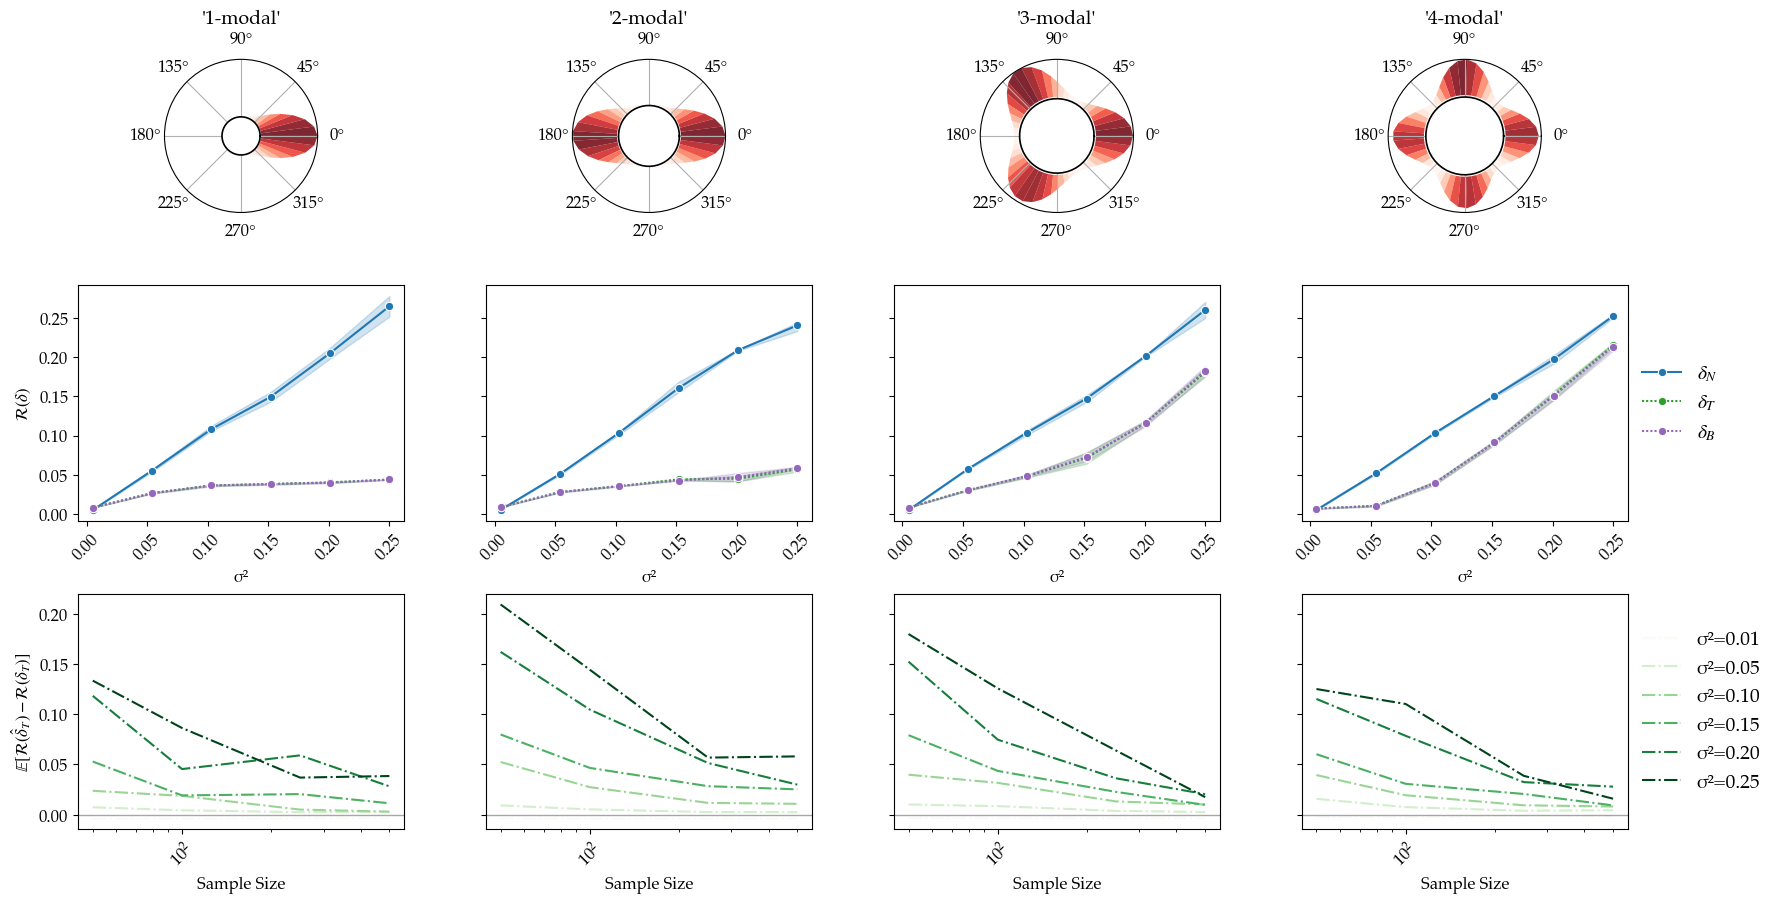

In [8]:
plot_mcsims(manifold_type, df_sigma, df_N, G_sampler_ls, savefig='{}mc'.format(manifold_type))

----

-------